# Bike Sales Analysis

## Import essential libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Exploration

In [2]:
# Read Excel file into dataframe
df = pd.read_excel("/Users/laingangiang/Downloads/Excel Notebook.xlsx")

In [3]:
# Display first rows of the dataframe
df.head()

,Product ID,Product Category,Product Subcategory,Product Name,Product Description,Product Price,Product Weight,Product Size,Order ID,Customer ID,Order Date,Order Status,Order Quantity,Order Total,Payment Method
0,1001,Mountain BIKES,Cross Country,TrailBlazer 1000,Lightweight and versatile,1200,25,M,2001,3001,2023-03-01,Shipped,2,2400,Credit Card
1,1002,Mountain Bikes,Cross Country,TrailBlazer 2000,High-performance mountain bike,1500,22,L,2002,3002,2023-03-02,Processing,1,1500,PayPal
2,1003,Road Bikes,Racing,SpeedMaster 1000,Agile and aerodynamic road bike,1800,18,S,2003,3003,2023-03-03,Cancelled,3,5400,Credit Card
3,1004,Road BIKES,Racing,SpeedMaster 2000,Premium racing road bike,2100,16,L,2004,3004,2023-03-04,Shipped,1,2100,Credit Card
4,1005,Touring Bikes,Long Distance,Explorer 1000,Comfortable and durable touring bike,1300,27,M,2005,3005,2023-03-05,Processing,2,2600,PayPal


In [4]:
# Display last rows of the dataframe
df.tail()

,Product ID,Product Category,Product Subcategory,Product Name,Product Description,Product Price,Product Weight,Product Size,Order ID,Customer ID,Order Date,Order Status,Order Quantity,Order Total,Payment Method
43,1104,BMX Bikes,Freestyle,FreestyleMaster 2000,Advanced freestyle BMX bike,600,23,L,2104,3104,2023-02-04,Shipped,1,600,Credit Card
44,1105,Mountain Bikes,Cross Country,XC-Rider 1000,Cross country mountain bike,1800,29,M,2105,3105,2023-02-05,Processing,2,3600,PayPal
45,1106,Mountain Bikes,Cross Country,XC-Rider 2000,High-performance cross country bike,2400,27,L,2106,3106,2023-02-06,Shipped,1,2400,Credit Card
46,1107,ROAD BIKES,Endurance,EnduranceElite 1000,Endurance road bike,2100,20,M,2107,3107,2023-02-07,Shipped,2,4200,PayPal
47,1108,Road Bikes,Endurance,EnduranceElite 2000,High-performance endurance road bike,2600,18,L,2108,3108,2023-02-08,Processing,1,2600,Credit Card


In [5]:
# Get descriptive statistics for the dataframe
df.describe()

,Product ID,Product Price,Product Weight,Order ID,Customer ID,Order Date,Order Quantity,Order Total
count,48.000000,48.000000,48.000000,48.000000,48.000000,48,48.000000,48.000000
mean,1054.500000,1967.708333,26.208333,2054.500000,3054.500000,2023-03-03 04:00:00,1.625000,3079.166667
min,1001.000000,150.000000,9.000000,2001.000000,3001.000000,2023-02-01 00:00:00,1.000000,200.000000
25%,1024.750000,1500.000000,20.750000,2024.750000,3024.750000,2023-02-22 18:00:00,1.000000,2075.000000
50%,1054.500000,2000.000000,27.000000,2054.500000,3054.500000,2023-03-04 12:00:00,1.500000,2600.000000
75%,1084.250000,2425.000000,30.500000,2084.250000,3084.250000,2023-03-14 06:00:00,2.000000,4000.000000
max,1108.000000,3700.000000,42.000000,2108.000000,3108.000000,2023-03-28 00:00:00,3.000000,8400.000000
std,34.595535,801.892017,7.466117,34.595535,34.595535,NaN,0.703336,1690.267300


In [6]:
# Display dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Product ID           48 non-null     int64         
 1   Product Category     48 non-null     object        
 2   Product Subcategory  48 non-null     object        
 3   Product Name         48 non-null     object        
 4   Product Description  48 non-null     object        
 5   Product Price        48 non-null     int64         
 6   Product Weight       48 non-null     int64         
 7   Product Size         48 non-null     object        
 8   Order ID             48 non-null     int64         
 9   Customer ID          48 non-null     int64         
 10  Order Date           48 non-null     datetime64[ns]
 11  Order Status         48 non-null     object        
 12  Order Quantity       48 non-null     int64         
 13  Order Total          48 non-null     

In [7]:
# Display the data types of each column
df.dtypes


Product ID                      int64
Product Category               object
Product Subcategory            object
Product Name                   object
Product Description            object
Product Price                   int64
Product Weight                  int64
Product Size                   object
Order ID                        int64
Customer ID                     int64
Order Date             datetime64[ns]
Order Status                   object
Order Quantity                  int64
Order Total                     int64
Payment Method                 object
dtype: object

In [8]:
# Payment method distribution by category
payment_by_category = df.groupby("Product Category")["Payment Method"].value_counts().unstack(fill_value=0)
print("Payment Method Distribution by Category:")
print(payment_by_category)

Payment Method Distribution by Category:
Payment Method    Credit Card  PayPal
Product Category                     
BMX Bikes                   2       0
E-Bikes                     2       2
Hybrid Bikes                1       1
Kids Bikes                  1       1
Mountain BIKES              1       0
Mountain Bikes              5       8
ROAD BIKES                  1       1
Road BIKES                  1       0
Road Bikes                  8       0
Touring Bikes               5       5
mountain BIKES              0       1
mountain bikes              1       0
road Bikes                  1       0


In [9]:
# Average order total by order status
avg_total_by_status = df.groupby("Order Status")["Order Total"].mean()
print("Average Order Total by Status:")
print(avg_total_by_status)

Average Order Total by Status:
Order Status
Cancelled     5150.000000
Processing    2616.666667
Shipped       2908.333333
Name: Order Total, dtype: float64


In [10]:
# Top 10 products by total revenue
top_products = df.groupby("Product Name")["Order Total"].sum().nlargest(10)
print("Top 10 Products by Total Revenue:")
print(top_products)

Top 10 Products by Total Revenue:
Product Name
AeroSpeed 1000            8400
E-TrailBlazer 1000        6400
E-Mountain 1000           6000
DownhillDominator 1000    5800
CrossRider 1000           5700
SpeedMaster 1000          5400
GravelMaster 1000         5100
Voyager 1000              5100
EnduroMaster 1000         4600
GravityMaster 1000        4400
Name: Order Total, dtype: int64


In [11]:
# Order quantity distribution by payment method
quantity_by_payment = df.groupby("Payment Method")["Order Quantity"].sum()
print("Total Order Quantity by Payment Method:")
print(quantity_by_payment)

Total Order Quantity by Payment Method:
Payment Method
Credit Card    47
PayPal         31
Name: Order Quantity, dtype: int64


In [12]:
# Average product price by subcategory
avg_price_by_subcategory = df.groupby("Product Subcategory")["Product Price"].mean().sort_values(ascending=False)
print("Average Product Price by Subcategory:")
print(avg_price_by_subcategory)

Average Product Price by Subcategory:
Product Subcategory
Mountain                    3450.0
Electric                    3250.0
Aero                        3000.0
Downhill                    2725.0
Enduro                      2450.0
Endurance                   2350.0
City                        2250.0
Recumbent                   2200.0
Tandem                      2150.0
Cyclocross                  2050.0
Racing                      1950.0
Gravel                      1900.0
Touring                     1850.0
Adventure                   1800.0
Cross Country               1725.0
Folding                     1650.0
Sucategory Not Available    1500.0
Fat Bikes                   1450.0
Long Distance               1450.0
Commuter                    1350.0
Trail                       1250.0
Freestyle                    500.0
Balance                      175.0
Name: Product Price, dtype: float64


## Visualization

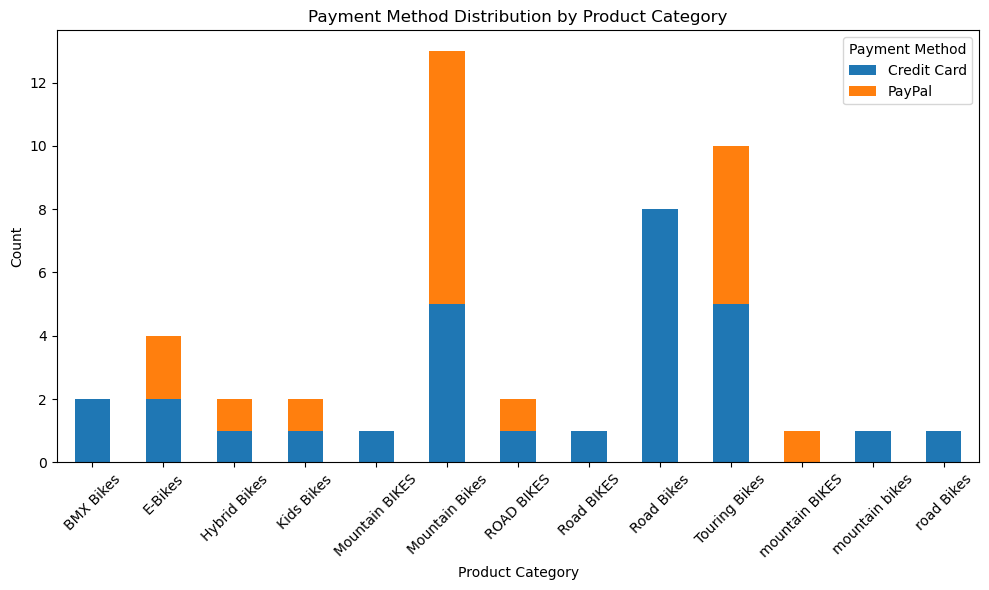

In [19]:
# Plot stacked bar chart for payment method distribution by product category
payment_by_category.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Payment Method Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Payment Method")
plt.tight_layout()
plt.show()

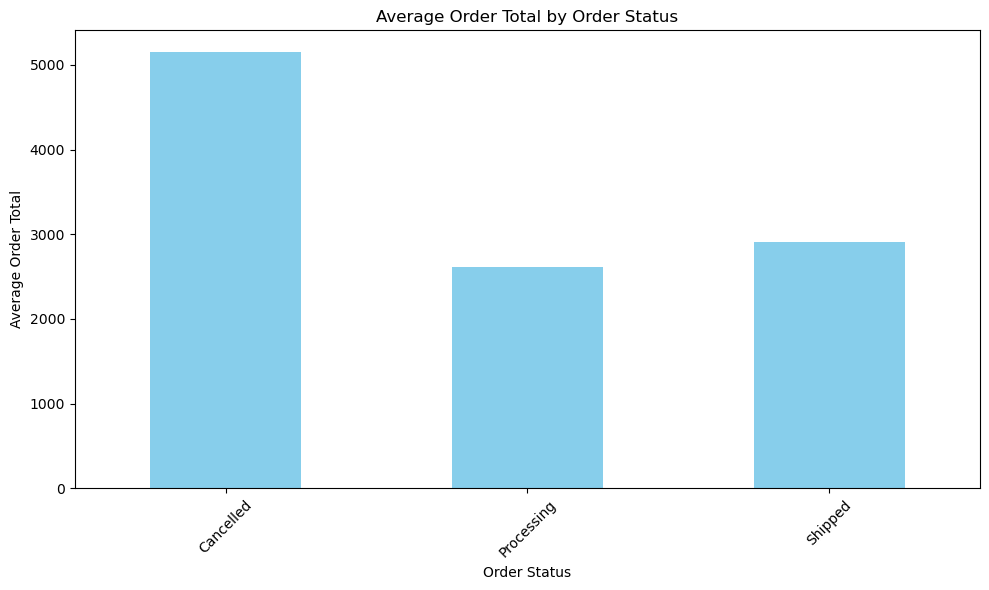

In [14]:
# Plot bar chart for average order total by order status
plt.figure(figsize=(10, 6))
avg_total_by_status.plot(kind="bar", color="skyblue")
plt.title("Average Order Total by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Order Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

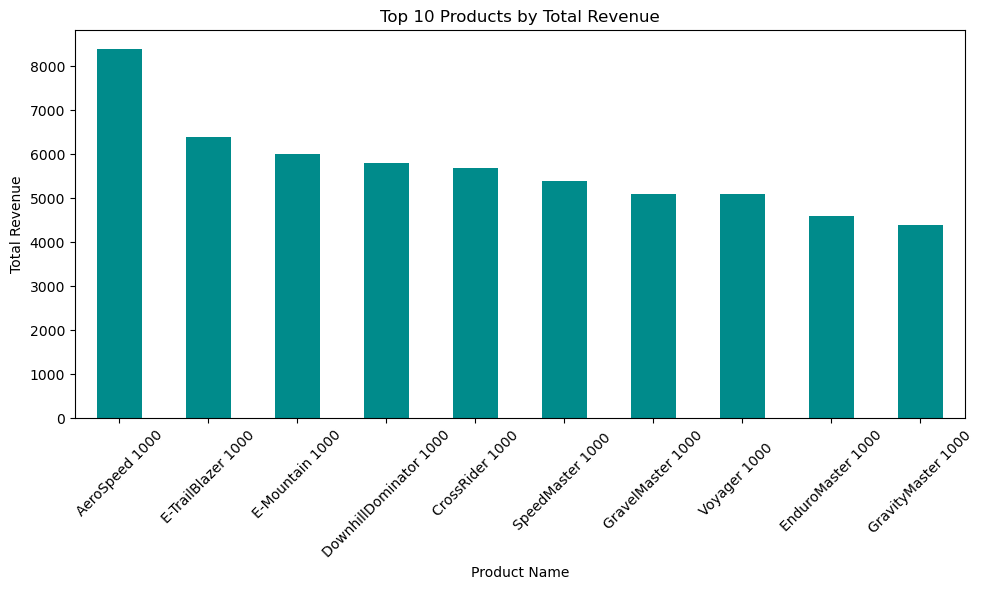

In [15]:
# Plot top 10 products by total revenue
plt.figure(figsize=(10, 6))
top_products.plot(kind="bar", color="darkcyan")
plt.title("Top 10 Products by Total Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

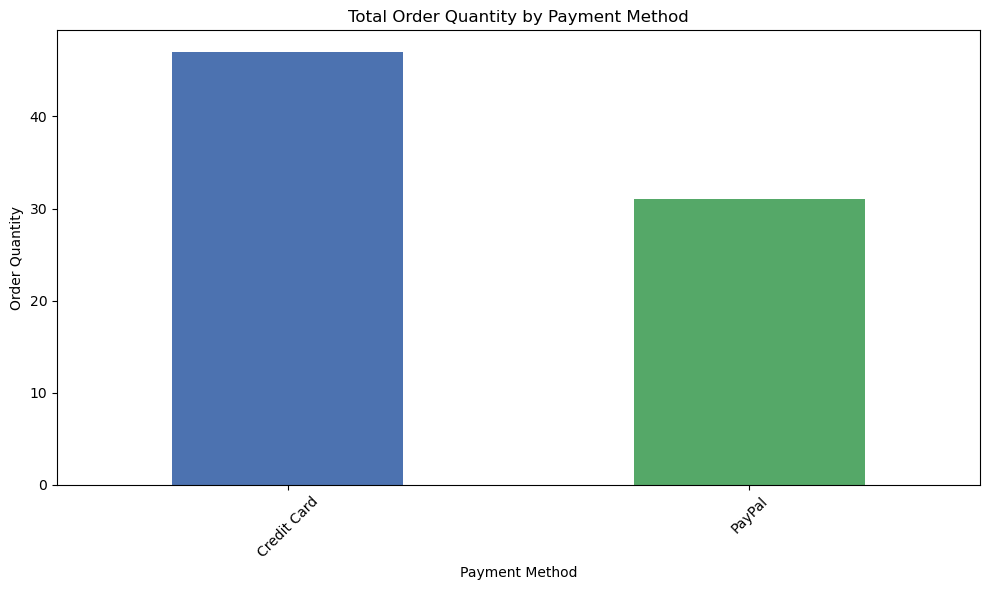

In [16]:
# Plot total order quantity by payment method
plt.figure(figsize=(10, 6))
quantity_by_payment.plot(kind="bar", color=["#4c72b0", "#55a868"])
plt.title("Total Order Quantity by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Order Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

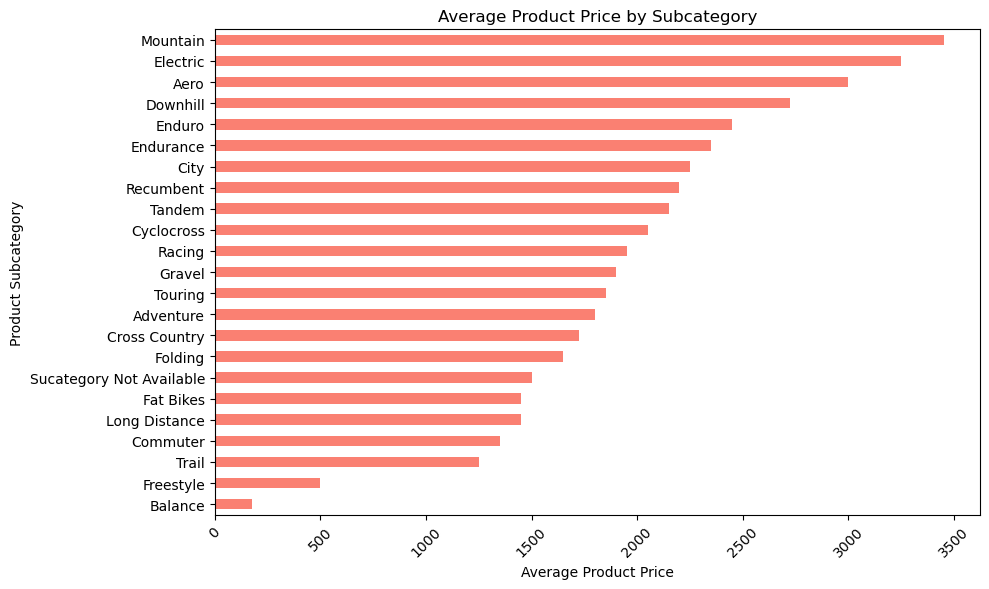

In [17]:
# Plot average product price by subcategory
plt.figure(figsize=(10, 6))
avg_price_by_subcategory.plot(kind="barh", color="salmon")
plt.title("Average Product Price by Subcategory")
plt.xlabel("Average Product Price")
plt.ylabel("Product Subcategory")
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()